In [1]:
import pickle
from pathlib import Path
import sys
import os
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score
import pandas as pd 
import torch.nn.functional as F


def get_auroc_aupr(in_uncertainty, out_uncertainty):
    # In-Distribution (ID) 데이터는 레이블 0
    in_labels = np.zeros(len(in_uncertainty))
    
    # Out-Of-Distribution (OOD) 데이터는 레이블 1
    out_labels = np.ones(len(out_uncertainty))
    
    # 레이블과 불확실성 값들을 결합
    labels = np.concatenate([in_labels, out_labels])
    uncertainties = np.concatenate([in_uncertainty, out_uncertainty])
    
    # AUROC 계산
    auroc = roc_auc_score(labels, uncertainties)
    
    # Precision-Recall 곡선 계산 및 AUPR 계산
    precision, recall, _ = precision_recall_curve(labels, uncertainties)
    aupr = auc(recall, precision)
    
    return auroc, aupr

import numpy as np
from sklearn.metrics import accuracy_score
import numpy as np

def aulc(labels, scores, reverse_sort=True):
    """
    Lift Curve 계산 및 AULC (Area Under the Lift Curve) 계산.
    
    
    Args:
        labels (np.array): 실제 레이블, 이진 또는 다중 클래스 (크기: [num_samples])
        scores (np.array): 불확실성 스코어 (크기: [num_samples])
        reverse_sort (bool): 내림차순 정렬 여부. 기본값은 False (오름차순 정렬)
    
    Returns:
        lift (np.array): 각 샘플에 대한 Lift 값
        x (np.array): x-축에 대한 스텝 값
        aulc (float): Lift Curve의 면적 (AULC)
    """
    n = labels.shape[0]

    # 불확실성 스코어에 따라 샘플 정렬
    if reverse_sort:
        sorted_idx = np.flip(np.argsort(scores), axis=0)
    else:
        sorted_idx = np.argsort(scores)
    sorted_labels = labels[sorted_idx]

    # Lift Curve 계산
    lift = np.zeros(n)
    lift[0] = sorted_labels[0] / np.mean(sorted_labels)  # 첫 번째 Lift 값
    _m = np.mean(sorted_labels)  # 전체 레이블의 평균

    for i in range(1, n):
        lift[i] = (i * lift[i - 1] + sorted_labels[i] / _m) / (i + 1)

    # x-축에 대한 스텝 값
    step = 1 / n
    return lift, np.arange(step, 1 + step, step), np.sum(lift) * step - 1


def compute_raulc(labels, scores):
    """
    rAULC 계산.
    
    Args:
        labels (np.array): 실제 레이블 (크기: [num_samples])
        scores (np.array): 불확실성 스코어 (크기: [num_samples])
    
    Returns:
        rAULC (float): 상대적인 Lift Curve 면적
    """
    # 현재 모델의 AULC 계산
    _, _, area = aulc(labels, scores)
    
    # 이상적인 모델의 AULC 계산 (레이블을 정렬된 순서로 전달)
    _, _, area_opt = aulc(labels, labels, reverse_sort=True)

    # rAULC 계산
    return area / area_opt if area_opt != 0 else 0

import torch

def compute_ece(softmax_probs, labels, num_bins=10):
    # 소프트맥스 확률에서 가장 높은 값과 그에 대응하는 예측 클래스 계산
    softmax_probs = torch.tensor(np.array(softmax_probs), dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.long)

    confidences, preds = torch.max(softmax_probs, dim=1)
    
    # 정확도 계산을 위해 올바른 예측 여부를 확인
    accuracies = preds.eq(labels)

    # ECE 계산을 위한 초기화
    ece = 0.0
    bin_boundaries = torch.linspace(0, 1, num_bins + 1)  # 0 ~ 1 사이의 구간 생성
    for i in range(num_bins):
        # 각 구간에 속하는 예측 인덱스
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        bin_mask = (confidences > bin_lower) & (confidences <= bin_upper)
        bin_size = bin_mask.sum().item()
        
        if bin_size > 0:
            # 구간 내의 평균 신뢰도와 정확도 계산
            bin_confidence = confidences[bin_mask].mean().item()
            bin_accuracy = accuracies[bin_mask].float().mean().item()
            
            # ECE에 구간 내 정확도와 신뢰도의 차이 반영
            ece += bin_size / len(labels) * abs(bin_confidence - bin_accuracy)

    return ece

import numpy as np

def AULC(accs, uncertainties):
  idxs = np.argsort(uncertainties)
  uncs_s = uncertainties[idxs]
  error_s = accs[idxs]

  mean_error = error_s.mean()
  error_csum = np.cumsum(error_s)

  Fs = error_csum / np.arange(1, len(error_s) + 1)
  s = 1 / len(Fs)
  return -1 + s * Fs.sum() / mean_error, Fs

def rAULC(uncertainties, accs):
    perf_aulc, Fsp = AULC(accs, -accs.astype("float"))
    curr_aulc, Fsc = AULC(accs, uncertainties)
    return curr_aulc / perf_aulc, Fsp, Fsc



In [6]:
data = 'cifar10'
method ='my'
seeds = [0,93,7777]
type = 'test'
model = "resnet18" 


accs = []
times = []
eces = []
raulcs = []
auroc_c = []
aupr_c = []
auroc_s = []
aupr_s = []


lists = [10,20,30,40,50,60,70,80,90]
p = 90
for seed in seeds:
    current_dir = os.getcwd()

    new_folder = f"result/{data}/{method}/{model}/threshold_30/seed_{seed}" #f"result1/{data}/{method}/{model}/seed_{seed}"
    file = f"{data}_test_{seed}.pkl"
    ood_file = f"{data}_ood_{seed}.pkl"
    full_path = os.path.join(current_dir, new_folder,file)
    ood_path = os.path.join(current_dir, new_folder,ood_file)

    with open(full_path, 'rb') as f:
        results = pickle.load(f)
    with open(ood_path, 'rb') as f:
        ood_results = pickle.load(f)
    
    distance = np.array([tensor.cpu().numpy() for tensor in results['distances']])
    ood_d = np.array([tensor.cpu().numpy() for tensor in ood_results['distances']])

    acc = results['acc']
    time = results['inference_times']
    ece = compute_ece(results['prob'],results['label'])
    res, _, _ = rAULC(np.array(distance),(np.array(results['pred']) == np.array(results['label'])))



    ood = pd.DataFrame({'pred': ood_results['pred'], 'label' : ood_results['label'], 'uncertaintiy':ood_d, 'type' : ood_results['type']})
    id = pd.DataFrame({'pred': results['pred'], 'label' :  np.array(results['label'], dtype=int),'uncertaintiy':distance, 'type' : results['type']})

    ood_c = ood[ood.type == 'cifar100_ood']['uncertaintiy'].values.tolist() # ood['uncertaintiy'].values.tolist()  #ood[ood.type == 'cifar100_ood']['uncertaintiy'].values.tolist() #cifar100_ood, svhn_ood ood['uncertaintiy'] 
    ood_s = ood[ood.type == 'svhn_ood']['uncertaintiy'].values.tolist() # ood['uncertaintiy'].values.tolist()  #ood[ood.type == 'cifar100_ood']['uncertaintiy'].values.tolist() #cifar100_ood, svhn_ood ood['uncertaintiy'] 
    in_u = id['uncertaintiy'].values.tolist() 
    
    au_c, aup_c = get_auroc_aupr(in_u, ood_c)
    au_s, aup_s = get_auroc_aupr(in_u, ood_s)

    accs.append(acc)
    times.append(time)
    eces.append(ece)
    raulcs.append(res)
    auroc_c.append(au_c)
    aupr_c.append(aup_c)
    auroc_s.append(au_s)
    aupr_s.append(aup_s)

    data_dict = {
    "Accuracy": accs,
    "Time": times,
    "ECE": eces,
    "RAULC": raulcs,
    "AUROC_C": auroc_c,
    "AUPR_C": aupr_c,
    "AUROC_S": auroc_s,
    "AUPR_S": aupr_s,
    }
    
    df = pd.DataFrame(data_dict)

    summary_row = {col: f"{np.mean(vals):.4f} ± {np.std(vals):.4f}" for col, vals in data_dict.items()}
    summary_df = pd.DataFrame(summary_row, index=["Summary"])
    df = pd.concat([df, summary_df], ignore_index=True)

    # 엑셀 파일로 저장


    fi = f"result/final/{data}_{model}_{method}_distance.xlsx"
    df.to_excel(fi, index=False)



In [100]:

accs = []

data = 'cifar10'
method ='zigzag'
seeds = [0,93,7777]
type = 'test'
model = "resnet34" 

ps = [1,0.95,0.9,0.85,0.8]

def calculate_accuracy(y_true, y_pred):
    return (y_true == y_pred).sum()/len(y_true)

for p in ps:
    accs = []
    for i in seeds:

        #저장 excel 파일 열기
        # Open the saved Excel file
        current_dir = os.getcwd()

        new_folder = f"result/{data}/{method}/{model}/seed_{i}" #f"result1/{data}/{method}/{model}/seed_{seed}"
        #new_folder = f"result/{data}/{method}/{model}/seed_{i}"
        file = f"{data}_test_{i}.pkl"
        full_path = os.path.join(current_dir, new_folder,file)

        with open(full_path, 'rb') as f:
            results = pickle.load(f)

        id = pd.DataFrame({'pred': results['pred'], 'label' :  np.array(results['label'], dtype=int),'uncertaintiy':results['uncertainty'], 'type' : results['type']})

        #uncertainty 상위 5%씩 제외하기 위한 과정
        #모든 값은 p = 1, 5%제외시 p = 0.95.......
        # Process to exclude the top 5% of uncertainty values
        # All values initially have p = 1, excluding 5% sets p = 0.95...
        threshold = id['uncertaintiy'].quantile(p) 
        id = id[id['uncertaintiy'] <= threshold].reset_index(drop = True)
        
        accs.append(calculate_accuracy(id['pred'], id['label'])*100)
    
    print(f"{p} acc : {np.mean(accs):.2f} ± {np.std(accs):.2f}")



1 acc : 68.13 ± 0.48
0.95 acc : 70.13 ± 0.66
0.9 acc : 72.15 ± 0.76
0.85 acc : 74.07 ± 0.73
0.8 acc : 76.17 ± 0.84


In [51]:
#1
lists = [30,40,50,60,70,80,90]

ECE = []
RAULC = []
AUROC_C = []
AUPR_C = []
AUROC_S = []
AUPR_S = []

data = 'cifar10'
model = 'resnet18'
method = 'my'

for p in lists: 
    df = pd.read_excel(f"result/final/{data}_{model}_{method}_{p}.xlsx")
    df.loc[len(df)] = df.iloc[3].apply( lambda x : float(x.split(' ')[0]))
    ECE.append(round(df.iloc[4,2],3))
    RAULC.append(df.iloc[4,3] * 100)
    AUROC_C.append(df.iloc[4,4] * 100)
    AUPR_C.append(df.iloc[4,5] * 100 )
    AUROC_S.append(df.iloc[4,6] * 100 )
    AUPR_S.append(df.iloc[4,7] * 100 )


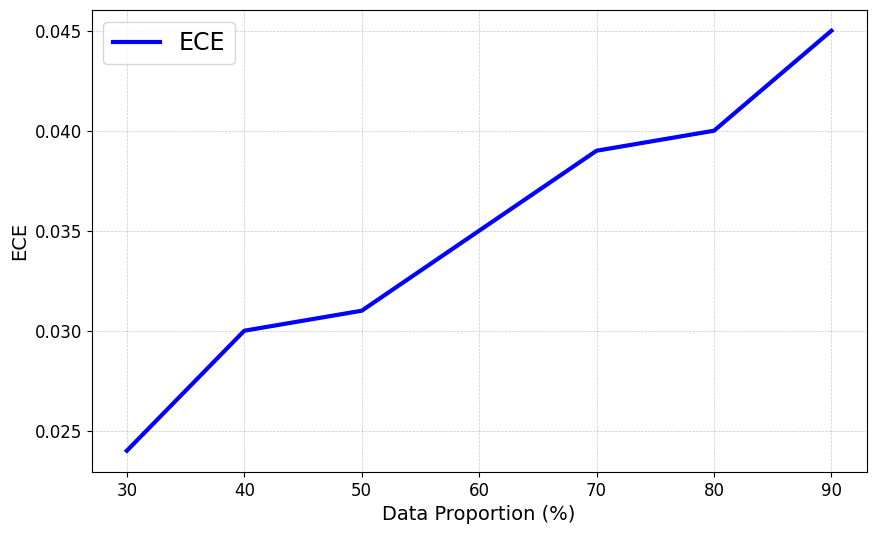

In [52]:
import matplotlib.pyplot as plt

# 기본 그래프 생성
fig, ax1 = plt.subplots(figsize=(10, 6))

# 첫 번째 리스트 series1 그리기 (ECE)
ax1.plot(lists, ECE, label="ECE", color='blue', linewidth=3)
ax1.set_xlabel("Data Proportion (%)", fontsize=14)
ax1.set_ylabel("ECE", fontsize=14)
ax1.tick_params(axis='y', labelsize=12)  # y축 숫자 크기 설정
ax1.tick_params(axis='x', labelsize=12)  # x축 숫자 크기 설정

# 격자 스타일 설정
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# 범례 추가
ax1.legend(loc="upper left", fontsize=17)

# 그래프 제목
#plt.title(f"{model} with {data}")

# 그래프 출력
plt.show()


In [99]:
#2 레벨에 따른 uncertainty   

data = 'cifar10'
method = 'zigzag'
model = 'resnet18'
seed = 7777

new_folder = f"result/{data}/{method}/{model}/seed_7777"      #/sampling_40/seed_0" f"result1/{data}/{method}/{model}/seed_{seed}"
file = f"{data}_test_{seed}.pkl"
ood_file = f"{data}_ood_{seed}.pkl"
full_path = os.path.join(current_dir, new_folder,file)
ood_path = os.path.join(current_dir, new_folder,ood_file)

with open(full_path, 'rb') as f:
    results = pickle.load(f)
with open(ood_path, 'rb') as f:
    ood_results = pickle.load(f)

ood = pd.DataFrame({'pred': ood_results['pred'], 'label' : ood_results['label'], 'Uncertainty':ood_results['uncertainty'], 'Sensitivity Level' : ood_results['type']})
id = pd.DataFrame({'pred': results['pred'], 'label' :  np.array(results['label'], dtype=int),'Uncertainty':results['uncertainty'], 'Sensitivity Level' : results['type']})

id['Sensitivity Level'] = id['Sensitivity Level'].apply(lambda x : x.item())
id['Uncertainty'] = id['Uncertainty'] 
ood['Uncertainty'] = ood['Uncertainty'] 
id['predict'] = (id['pred'] == id['label'])

In [85]:
for i in range(6): 
    df = id[id['Sensitivity Level'] == i]
    acc = sum(df['pred'] == df['label'])/len(df)
    print(f"{i} acc : {acc}")

0 acc : 0.832
1 acc : 0.8146666666666667
2 acc : 0.76
3 acc : 0.7373333333333333
4 acc : 0.682
5 acc : 0.604


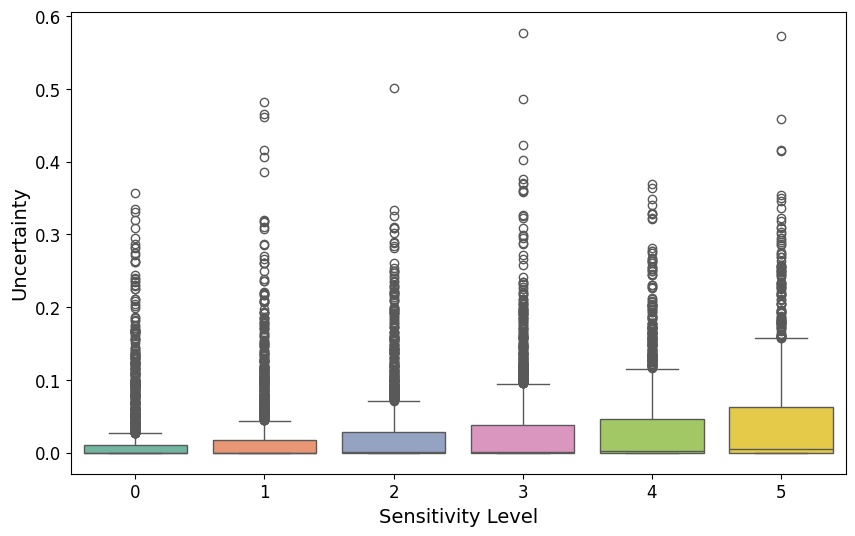

In [72]:
import seaborn as sns
import warnings 
import matplotlib.pyplot as plt

warnings.filterwarnings(action = 'ignore')

# 박스플롯 그리기
plt.figure(figsize=(10, 6))
sns.boxplot(data=id, x='Sensitivity Level', y='Uncertainty', palette='Set2')  # Set3 컬러맵 사용
#plt.title(f"Uncertainty boxplot by Sensitivity Level({method})", fontsize=16)
plt.xlabel('Sensitivity Level', fontsize=14)
plt.ylabel('Uncertainty', fontsize=14)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기

plt.show()

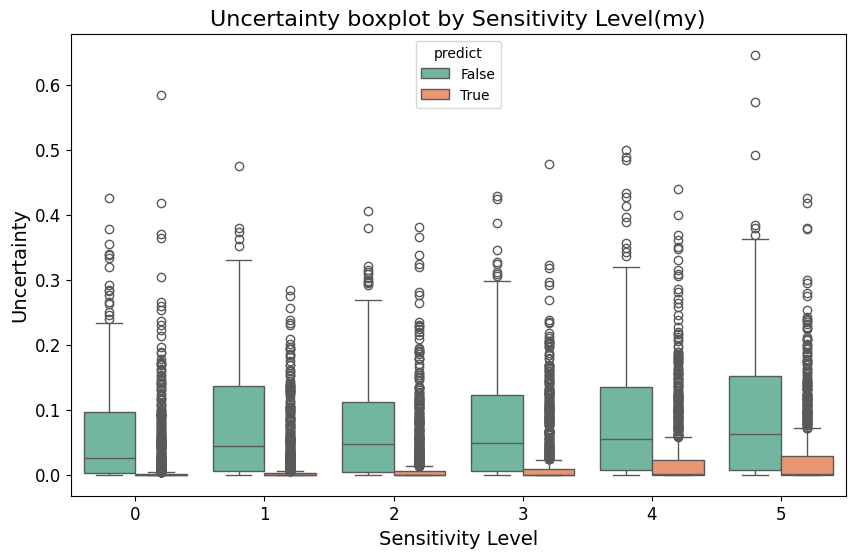

In [24]:
# 이 두개는 다른것들도 봐보쟈! 
import seaborn as sns
import warnings 
warnings.filterwarnings(action = 'ignore')

# 박스플롯 그리기
plt.figure(figsize=(10, 6))
sns.boxplot(data=id, x='Sensitivity Level', y='Uncertainty', hue = 'predict', palette='Set2')  # Set3 컬러맵 사용
plt.title(f'Uncertainty boxplot by Sensitivity Level({method})', fontsize=16)
plt.xlabel('Sensitivity Level', fontsize=14)
plt.ylabel('Uncertainty', fontsize=14)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기

plt.show()

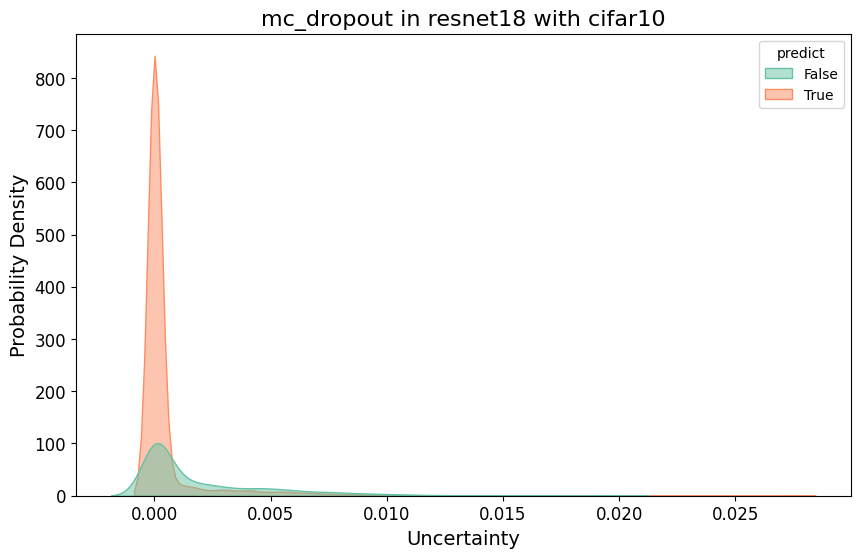

In [31]:
# 맞고 아니고 따른 그래프 

import seaborn as sns
import matplotlib.pyplot as plt

# 히스토그램과 KDE 그래프 그리기
plt.figure(figsize=(10, 6))
sns.kdeplot(data=id, x='Uncertainty', hue='predict',  palette='Set2', alpha=0.5, fill=True)
plt.title(f'{method} in {model} with {data}', fontsize=16)
plt.xlabel('Uncertainty',  fontsize=14)
plt.ylabel('Probability Density',  fontsize=14)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기

plt.show()

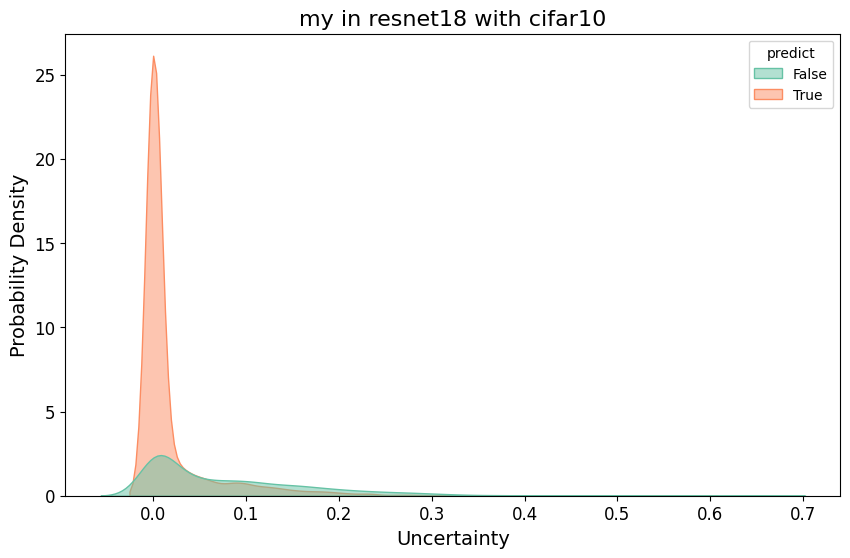

In [26]:
# 맞고 아니고 따른 그래프 

import seaborn as sns
import matplotlib.pyplot as plt

# 히스토그램과 KDE 그래프 그리기
plt.figure(figsize=(10, 6))
sns.kdeplot(data=id, x='Uncertainty', hue='predict',  palette='Set2', alpha=0.5, fill=True)
plt.title(f'{method} in {model} with {data}', fontsize=16)
plt.xlabel('Uncertainty',  fontsize=14)
plt.ylabel('Probability Density',  fontsize=14)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기

plt.show()

In [36]:
#ID OOD
id['Data Type'] = 'ID'
ood['Data Type'] = ood['Sensitivity Level'].map({'cifar100_ood': 'OOD_CIFAR100',
                                         'svhn_ood' : 'OOD_SVHN'})
id_2 = id[['Data Type', 'Uncertainty']]
ood_2 = ood[['Data Type', 'Uncertainty']]
id_ood = pd.concat([id_2,ood_2], axis = 0)

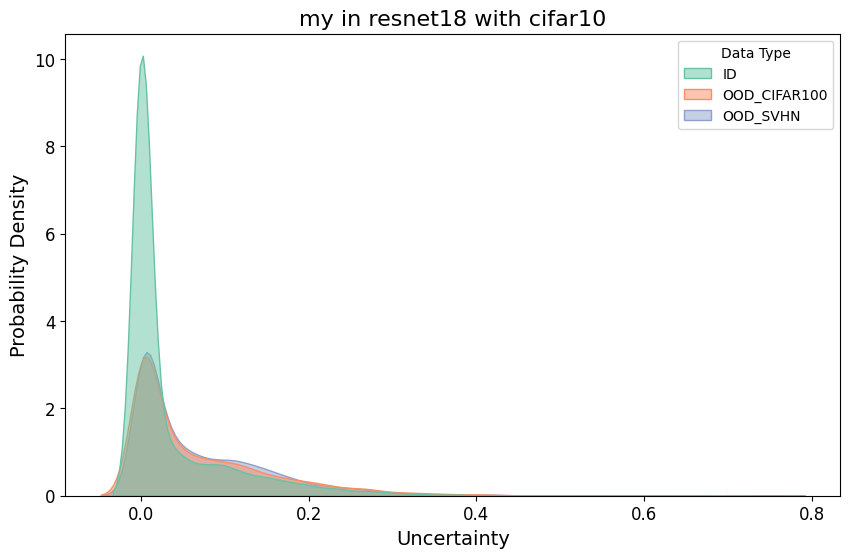

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
# 맞고 아니고 따른 그래프 

# 히스토그램과 KDE 그래프 그리기
plt.figure(figsize=(10, 6))
sns.kdeplot(data=id_ood, x='Uncertainty', hue='Data Type', palette='Set2', alpha=0.5, fill=True)
plt.title(f'{method} in {model} with {data}', fontsize=16)
plt.xlabel('Uncertainty', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기

plt.show()

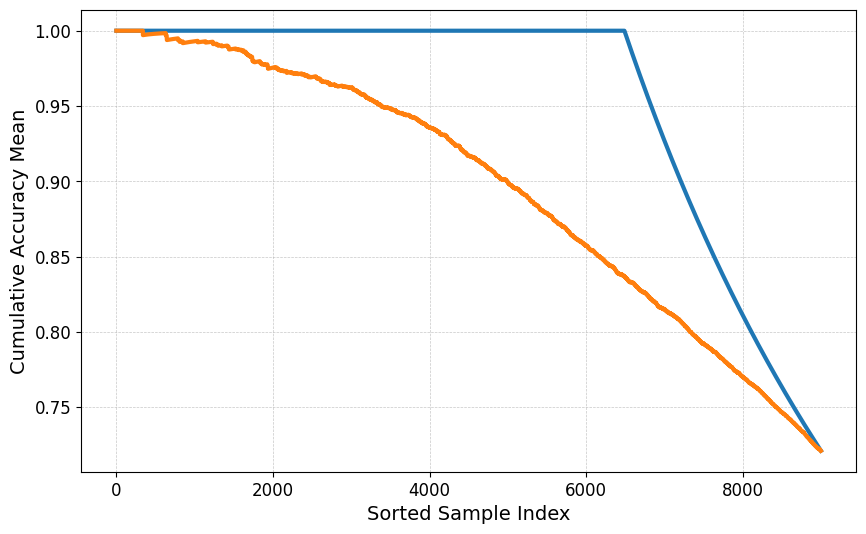

In [29]:
#rAULC 그래프벼롤 다 그려서 확인하기 
res, r1, r2 = rAULC(np.array(results['uncertainty']),(np.array(results['pred']) == np.array(results['label'])))
plt.figure(figsize=(10, 6))

plt.xlabel("Sorted Sample Index", fontsize=14)  # x축 이름
plt.ylabel("Cumulative Accuracy Mean", fontsize=14)  # y축 이름
plt.plot(range(len(r1)), r1, linewidth=3)
plt.plot(range(len(r1)), r2, linewidth=3)
plt.grid(linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기

plt.show()

In [ ]:
#OOD/ID나누어서 uncertainty 분포 확인 
#ID내에서 틀린거 맞은거에 다라서 uncertainty 분포 확인  

In [443]:
#~별 box plot 
seed = 7777
ensemble_path = f"result/cifar10/ensemble/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
masked_path = f"result/cifar10/masked_ensemble/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
mc_dropout_path = f"result/cifar10/mc_dropout/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
normal_path = f"result/cifar10/normal/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
zigzag_path = f"result/cifar10/zigzag/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
my_path = f"result/cifar10/my/resnet34/thresold_30/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"

with open(ensemble_path, 'rb') as f:
    ensemble_results = pickle.load(f)
with open(masked_path, 'rb') as f:
    masked_results = pickle.load(f)
with open(mc_dropout_path, 'rb') as f:
    mc_dropout_results = pickle.load(f)
with open(normal_path, 'rb') as f:
    normal_results = pickle.load(f)
with open(zigzag_path, 'rb') as f:
    zigzag_results = pickle.load(f)
with open(my_path, 'rb') as f:
    my_results = pickle.load(f)

ensemble = pd.DataFrame({'pred': ensemble_results['pred'], 'label' :  np.array(ensemble_results['label'], dtype=int),'Uncertainty':ensemble_results['uncertainty'], 'Sensitivity Level' : ensemble_results['type']})
masked = pd.DataFrame({'pred': masked_results['pred'], 'label' :  np.array(masked_results['label'], dtype=int),'Uncertainty':masked_results['uncertainty'], 'Sensitivity Level' : masked_results['type']})
mc_dropout = pd.DataFrame({'pred': mc_dropout_results['pred'], 'label' :  np.array(mc_dropout_results['label'], dtype=int),'Uncertainty':mc_dropout_results['uncertainty'], 'Sensitivity Level' : mc_dropout_results['type']})
normal = pd.DataFrame({'pred': normal_results['pred'], 'label' :  np.array(normal_results['label'], dtype=int),'Uncertainty':normal_results['uncertainty'], 'Sensitivity Level' : normal_results['type']})
zigzag = pd.DataFrame({'pred': zigzag_results['pred'], 'label' :  np.array(zigzag_results['label'], dtype=int),'Uncertainty':zigzag_results['uncertainty'], 'Sensitivity Level' : zigzag_results['type']})
my = pd.DataFrame({'pred': my_results['pred'], 'label' :  np.array(my_results['label'], dtype=int),'Uncertainty':my_results['uncertainty'], 'Sensitivity Level' : my_results['type']})

ensemble['Method'] = 'Ensemble'
masked['Method'] = 'Masked ensemble'
mc_dropout['Method'] = 'Mc dropout'
normal['Method'] = 'Deterministic'
zigzag['Method'] = 'ZigZag'
my['Method'] = 'Ours'

In [235]:
ensemble['normalized_value'] = ensemble['Uncertainty'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
masked['normalized_value'] = masked['Uncertainty'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
mc_dropout['normalized_value'] = mc_dropout['Uncertainty'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
normal['normalized_value'] = normal['Uncertainty'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
zigzag['normalized_value'] = zigzag['Uncertainty'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)
my['normalized_value'] = my['Uncertainty'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

In [236]:
df_all = pd.concat([ensemble, masked, mc_dropout, normal, zigzag,my], ignore_index=True)
df_all['answer'] = (df_all['pred'] == df_all['label'])
#df_all['normalized_value'] = df_all.groupby('Method')['Uncertainty'].transform(
#    lambda x: (x - x.min()) / (x.max() - x.min())
#)
df_all['Sensitivity Level'] = df_all['Sensitivity Level'].apply(lambda x : x.item())
df_all.head()

,pred,label,Uncertainty,Sensitivity Level,Method,normalized_value,answer
0,7,7,2.902839e-02,0,Ensemble,3.567748e-01,True
1,3,3,8.582278e-07,0,Ensemble,1.054809e-05,True
2,1,1,1.894246e-09,0,Ensemble,2.328133e-08,True
3,7,7,1.058524e-05,0,Ensemble,1.300984e-04,True
4,9,9,3.286635e-12,0,Ensemble,4.039455e-11,True


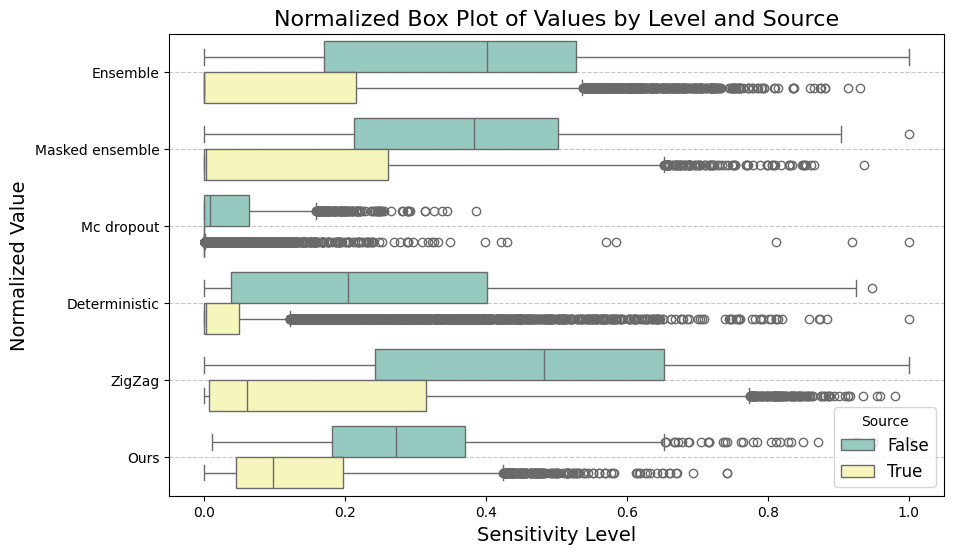

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all, x='normalized_value', y='Method', hue='answer', palette='Set3')
#맞고 틀리고에 따른 비율~ 
# 그래프 꾸미기
plt.title("Normalized Box Plot of Values by Level and Source", fontsize=16)
plt.xlabel("Sensitivity Level", fontsize=14)
plt.ylabel("Normalized Value", fontsize=14)
plt.legend(title="Source", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.show()

In [238]:
#AUROC

In [444]:
seed = 93
ensemble_path = f"result/cifar10/ensemble/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
masked_path = f"result/cifar10/masked_ensemble/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
mc_dropout_path = f"result/cifar10/mc_dropout/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
normal_path = f"result/cifar10/normal/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
zigzag_path = f"result/cifar10/zigzag/resnet34/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
my_path = f"result/cifar10/my/resnet34/thresold_30/seed_{seed}/cifar10_test_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"

with open(ensemble_path, 'rb') as f:
    ensemble_results = pickle.load(f)
with open(masked_path, 'rb') as f:
    masked_results = pickle.load(f)
with open(mc_dropout_path, 'rb') as f:
    mc_dropout_results = pickle.load(f)
with open(normal_path, 'rb') as f:
    normal_results = pickle.load(f)
with open(zigzag_path, 'rb') as f:
    zigzag_results = pickle.load(f)
with open(my_path, 'rb') as f:
    my_results = pickle.load(f)

ensemble = pd.DataFrame({'pred': ensemble_results['pred'], 'label' :  np.array(ensemble_results['label'], dtype=int),'Uncertainty':ensemble_results['uncertainty'], 'Sensitivity Level' : ensemble_results['type']})
masked = pd.DataFrame({'pred': masked_results['pred'], 'label' :  np.array(masked_results['label'], dtype=int),'Uncertainty':masked_results['uncertainty'], 'Sensitivity Level' : masked_results['type']})
mc_dropout = pd.DataFrame({'pred': mc_dropout_results['pred'], 'label' :  np.array(mc_dropout_results['label'], dtype=int),'Uncertainty':mc_dropout_results['uncertainty'], 'Sensitivity Level' : mc_dropout_results['type']})
normal = pd.DataFrame({'pred': normal_results['pred'], 'label' :  np.array(normal_results['label'], dtype=int),'Uncertainty':normal_results['uncertainty'], 'Sensitivity Level' : normal_results['type']})
zigzag = pd.DataFrame({'pred': zigzag_results['pred'], 'label' :  np.array(zigzag_results['label'], dtype=int),'Uncertainty':zigzag_results['uncertainty'], 'Sensitivity Level' : zigzag_results['type']})
my = pd.DataFrame({'pred': my_results['pred'], 'label' :  np.array(my_results['label'], dtype=int),'Uncertainty':my_results['uncertainty'], 'Sensitivity Level' : my_results['type']})

ensemble['Method'] = 'Ensemble'
masked['Method'] = 'Masked ensemble'
mc_dropout['Method'] = 'Mc dropout'
normal['Method'] = 'Deterministic'
zigzag['Method'] = 'ZigZag'
my['Method'] = 'Ours'

In [445]:
ensemble_patho = f"result/cifar10/ensemble/resnet34/seed_{seed}/cifar10_ood_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
masked_patho = f"result/cifar10/masked_ensemble/resnet34/seed_{seed}/cifar10_ood_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
mc_dropout_patho = f"result/cifar10/mc_dropout/resnet34/seed_{seed}/cifar10_ood_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
normal_patho = f"result/cifar10/normal/resnet34/seed_{seed}/cifar10_ood_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
zigzag_patho = f"result/cifar10/zigzag/resnet34/seed_{seed}/cifar10_ood_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"
my_patho = f"result/cifar10/my/resnet34/thresold_30/seed_{seed}/cifar10_ood_{seed}.pkl" #"result/cifar10/ensemble/resnet18/thresold_50/seed_0"

with open(ensemble_patho, 'rb') as f:
    ensemble_resultso = pickle.load(f)
with open(masked_patho, 'rb') as f:
    masked_resultso = pickle.load(f)
with open(mc_dropout_patho, 'rb') as f:
    mc_dropout_resultso = pickle.load(f)
with open(normal_patho, 'rb') as f:
    normal_resultso = pickle.load(f)
with open(zigzag_patho, 'rb') as f:
    zigzag_resultso = pickle.load(f)
with open(my_patho, 'rb') as f:
    my_resultso = pickle.load(f)

ensembleo = pd.DataFrame({'pred': ensemble_resultso['pred'], 'label' :  np.array(ensemble_resultso['label'], dtype=int),'Uncertainty':ensemble_resultso['uncertainty'], 'Sensitivity Level' : ensemble_resultso['type']})
maskedo = pd.DataFrame({'pred': masked_resultso['pred'], 'label' :  np.array(masked_resultso['label'], dtype=int),'Uncertainty':masked_resultso['uncertainty'], 'Sensitivity Level' : masked_resultso['type']})
mc_dropouto = pd.DataFrame({'pred': mc_dropout_resultso['pred'], 'label' :  np.array(mc_dropout_resultso['label'], dtype=int),'Uncertainty':mc_dropout_resultso['uncertainty'], 'Sensitivity Level' : mc_dropout_resultso['type']})
normalo = pd.DataFrame({'pred': normal_resultso['pred'], 'label' :  np.array(normal_resultso['label'], dtype=int),'Uncertainty':normal_resultso['uncertainty'], 'Sensitivity Level' : normal_resultso['type']})
zigzago = pd.DataFrame({'pred': zigzag_resultso['pred'], 'label' :  np.array(zigzag_resultso['label'], dtype=int),'Uncertainty':zigzag_resultso['uncertainty'], 'Sensitivity Level' : zigzag_resultso['type']})
myo = pd.DataFrame({'pred': my_resultso['pred'], 'label' :  np.array(my_resultso['label'], dtype=int),'Uncertainty':my_resultso['uncertainty'], 'Sensitivity Level' : my_resultso['type']})

ensembleo['Method'] = 'Ensemble'
maskedo['Method'] = 'Masked ensemble'
mc_dropouto['Method'] = 'Mc dropout'
normalo['Method'] = 'Deterministic'
zigzago['Method'] = 'ZigZag'
myo['Method'] = 'Ours'

In [446]:
id_unc = pd.concat([ensemble[['Method','Uncertainty']], masked[['Method','Uncertainty']] , mc_dropout[['Method','Uncertainty']],
                    normal[['Method','Uncertainty']], zigzag[['Method','Uncertainty']], my[['Method','Uncertainty']]], axis = 0)

In [447]:
ood_unc = pd.concat([ensembleo[['Method','Uncertainty','Sensitivity Level']], maskedo[['Method','Uncertainty','Sensitivity Level']] , mc_dropouto[['Method','Uncertainty','Sensitivity Level']],
                    normalo[['Method','Uncertainty', 'Sensitivity Level']], zigzago[['Method','Uncertainty','Sensitivity Level']], myo[['Method','Uncertainty', 'Sensitivity Level']]], axis = 0)

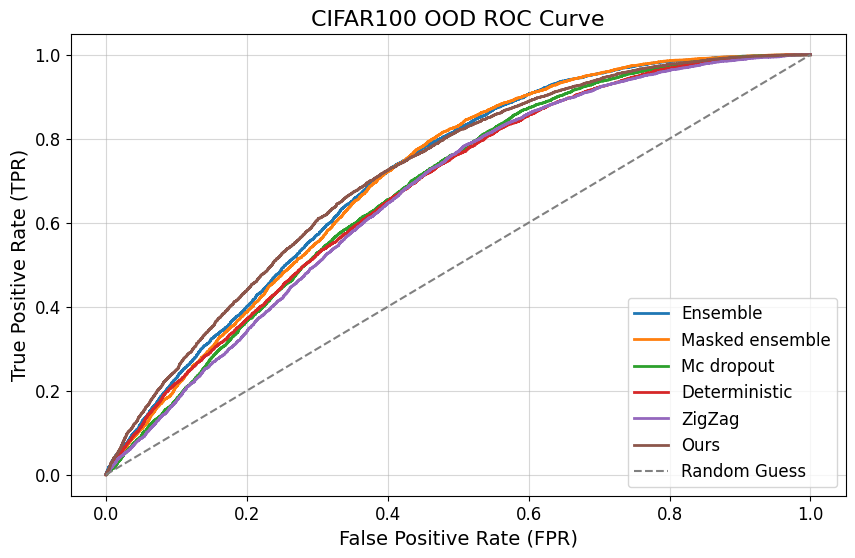

In [448]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models = ['Ensemble','Masked ensemble','Mc dropout', 'Deterministic', 'ZigZag', 'Ours']

ood_cifar = ood_unc[ood_unc['Sensitivity Level'] == 'cifar100_ood']
ood_shvn = ood_unc[ood_unc['Sensitivity Level'] == 'cifar100_shvn']


plt.figure(figsize=(10, 6))

for model in models:
    in_uncertainty = id_unc[id_unc.Method == model]['Uncertainty'].values.tolist()
    out_uncertainty = ood_cifar[ood_cifar.Method == model]['Uncertainty'].values.tolist()

    in_labels = np.zeros(len(in_uncertainty))
    out_labels = np.ones(len(out_uncertainty))
    
    # 레이블과 불확실성 값 결합
    labels_combined = np.concatenate([in_labels, out_labels])
    uncertainties_combined = np.concatenate([in_uncertainty, out_uncertainty])
    
    # ROC Curve 계산
    fpr, tpr, _ = roc_curve(labels_combined, uncertainties_combined)
    auroc = auc(fpr, tpr)
    
    # ROC Curve 그리기
    plt.plot(fpr, tpr, label=model, linewidth=2)

# 랜덤 추측 기준선 추가
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Random Guess")

# 그래프 꾸미기
plt.title("CIFAR100 OOD ROC Curve", fontsize=16)
plt.xlabel("False Positive Rate (FPR)", fontsize=14)
plt.ylabel("True Positive Rate (TPR)", fontsize=14)
plt.legend(fontsize=12, loc="lower right")
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.grid(alpha=0.5)
plt.show()

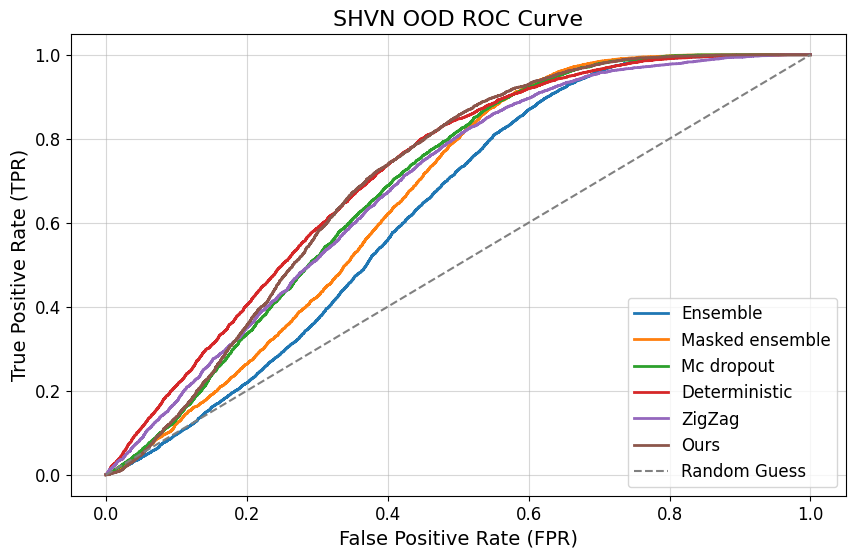

In [449]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models = ['Ensemble','Masked ensemble','Mc dropout', 'Deterministic', 'ZigZag', 'Ours']

ood_shvn = ood_unc[ood_unc['Sensitivity Level'] == 'svhn_ood']


plt.figure(figsize=(10, 6))

for model in models:
    in_uncertainty = id_unc[id_unc.Method == model]['Uncertainty'].values.tolist()
    out_uncertainty = ood_shvn[ood_shvn.Method == model]['Uncertainty'].values.tolist()

    in_labels = np.zeros(len(in_uncertainty))
    out_labels = np.ones(len(out_uncertainty))
    
    # 레이블과 불확실성 값 결합
    labels_combined = np.concatenate([in_labels, out_labels])
    uncertainties_combined = np.concatenate([in_uncertainty, out_uncertainty])
    
    # ROC Curve 계산
    fpr, tpr, _ = roc_curve(labels_combined, uncertainties_combined)
    auroc = auc(fpr, tpr)
    
    # ROC Curve 그리기
    plt.plot(fpr, tpr, label=model, linewidth=2)

# 랜덤 추측 기준선 추가
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Random Guess")

# 그래프 꾸미기
plt.title("SHVN OOD ROC Curve", fontsize=16)
plt.xlabel("False Positive Rate (FPR)", fontsize=14)
plt.ylabel("True Positive Rate (TPR)", fontsize=14)
plt.legend(fontsize=12, loc="lower right")
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.grid(alpha=0.5)
plt.show()

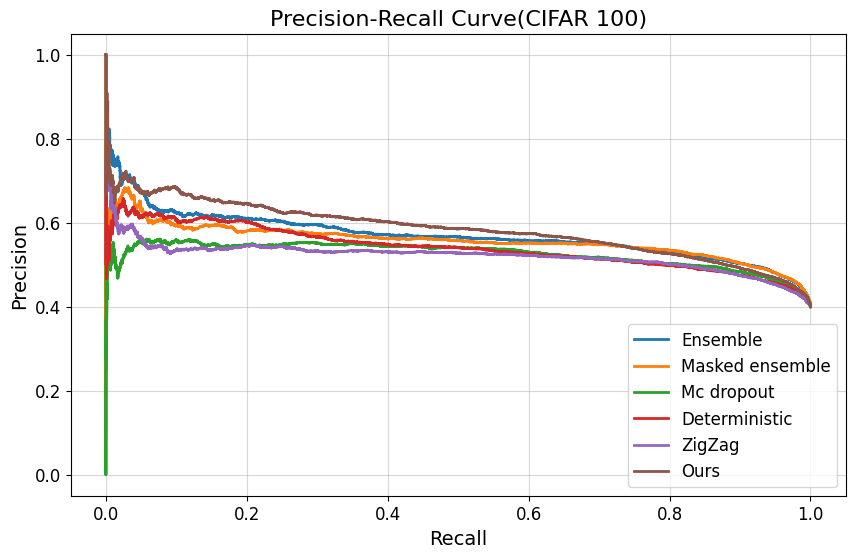

In [450]:

plt.figure(figsize=(10, 6))

for model in models:
    in_uncertainty = id_unc[id_unc.Method == model]['Uncertainty'].values.tolist()
    out_uncertainty = ood_cifar[ood_cifar.Method == model]['Uncertainty'].values.tolist()

    in_labels = np.zeros(len(in_uncertainty))
    out_labels = np.ones(len(out_uncertainty))
    
    # 레이블과 불확실성 값 결합
    labels_combined = np.concatenate([in_labels, out_labels])
    uncertainties_combined = np.concatenate([in_uncertainty, out_uncertainty])

    precision, recall, _ = precision_recall_curve(labels_combined, uncertainties_combined)
    aupr = auc(recall, precision)
    # ROC Curve 그리기
    plt.plot(recall, precision, label=model, linewidth=2)


# 그래프 꾸미기
plt.title("Precision-Recall Curve(CIFAR 100)", fontsize=16)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.legend(fontsize=12, loc="lower right")
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.grid(alpha=0.5)
plt.show()

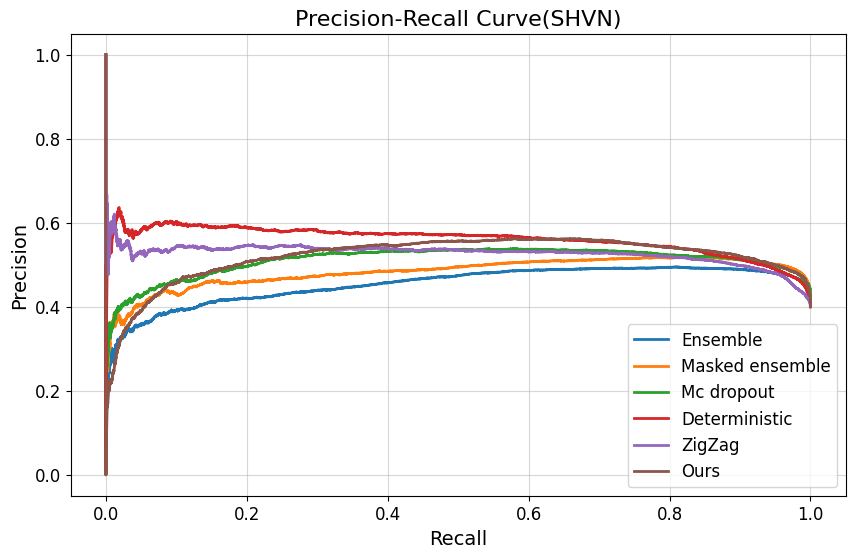

In [451]:

plt.figure(figsize=(10, 6))

for model in models:
    in_uncertainty = id_unc[id_unc.Method == model]['Uncertainty'].values.tolist()
    out_uncertainty = ood_shvn[ood_shvn.Method == model]['Uncertainty'].values.tolist()

    in_labels = np.zeros(len(in_uncertainty))
    out_labels = np.ones(len(out_uncertainty))
    
    # 레이블과 불확실성 값 결합
    labels_combined = np.concatenate([in_labels, out_labels])
    uncertainties_combined = np.concatenate([in_uncertainty, out_uncertainty])

    precision, recall, _ = precision_recall_curve(labels_combined, uncertainties_combined)
    aupr = auc(recall, precision)
    # ROC Curve 그리기
    plt.plot(recall, precision, label=model, linewidth=2)

# 그래프 꾸미기
plt.title("Precision-Recall Curve(SHVN)", fontsize=16)
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.legend(fontsize=12, loc="lower right")
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.grid(alpha=0.5)
plt.show()

In [313]:
#sampling에 관련한 
#1
lists = [1,10,20,30,40,50]

ECE = []
RAULC = []
AUROC_C = []
AUPR_C = []
AUROC_S = []
AUPR_S = []
ACC = []

data = 'cifar10'
model = 'resnet34'
method = 'my'

for p in lists: 
    df = pd.read_excel(f"result/final/{data}_{model}_{method}_sampling_{p}.xlsx")
    df.loc[len(df)] = df.iloc[3].apply( lambda x : float(x.split(' ')[0]))
    ECE.append(round(df.iloc[4,2],3))
    RAULC.append(df.iloc[4,3] * 100)
    AUROC_C.append(df.iloc[4,4] * 100)
    AUPR_C.append(df.iloc[4,5] * 100 )
    AUROC_S.append(df.iloc[4,6] * 100 )
    AUPR_S.append(df.iloc[4,7] * 100 )
    ACC.append(df.iloc[4,0] * 100)


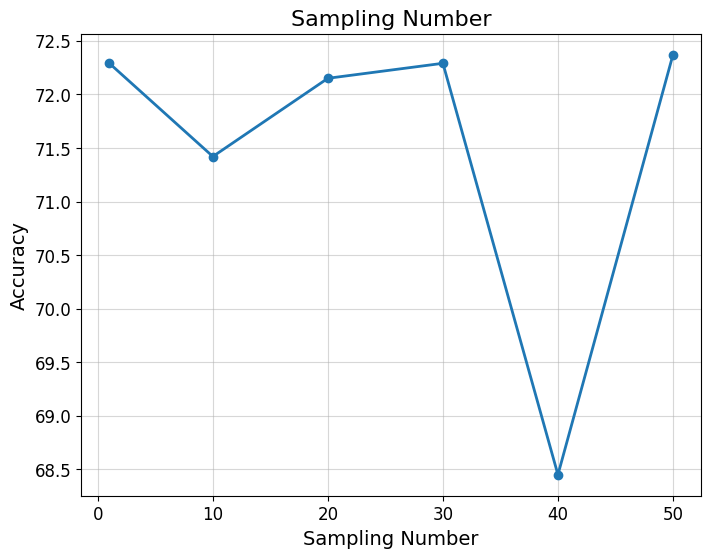

In [314]:
plt.figure(figsize=(8, 6))
plt.plot(lists, ACC, marker='o', label='Data Points', linewidth=2)

# 그래프 꾸미기
plt.title("Sampling Number", fontsize=16)
plt.xlabel("Sampling Number", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.show()

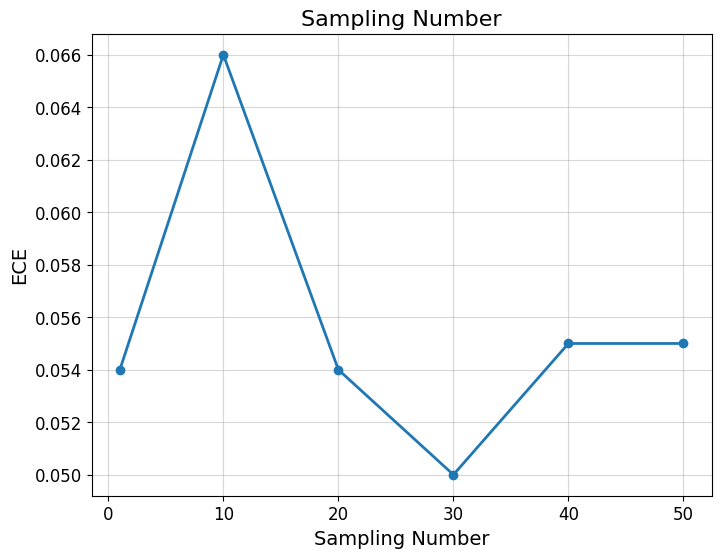

In [301]:
plt.figure(figsize=(8, 6))
plt.plot(lists, ECE, marker='o', label='Data Points', linewidth=2)

# 그래프 꾸미기
plt.title("Sampling Number", fontsize=16)
plt.xlabel("Sampling Number", fontsize=14)
plt.ylabel("ECE", fontsize=14)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.show()

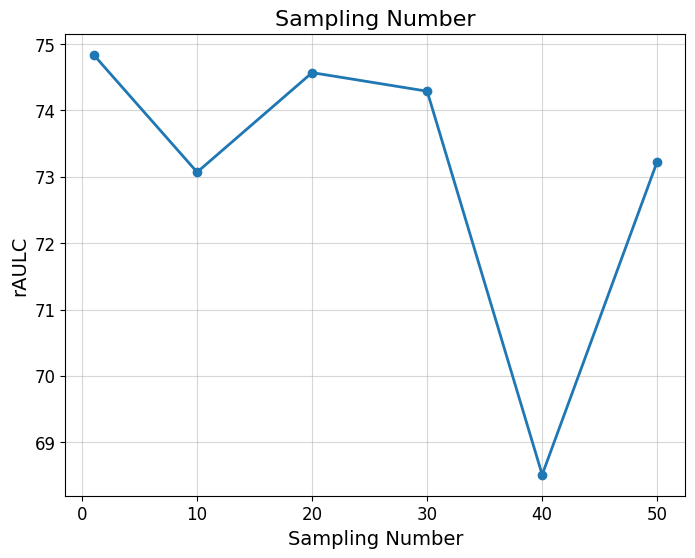

In [315]:
plt.figure(figsize=(8, 6))
plt.plot(lists, RAULC, marker='o', label='Data Points', linewidth=2)

# 그래프 꾸미기
plt.title("Sampling Number", fontsize=16)
plt.xlabel("Sampling Number", fontsize=14)
plt.ylabel("rAULC", fontsize=14)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.show()

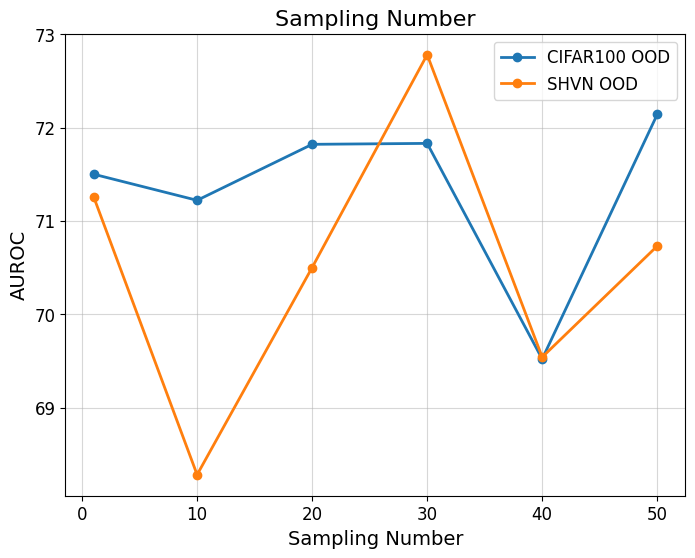

In [317]:
plt.figure(figsize=(8, 6))
plt.plot(lists, AUROC_C, marker='o', label='CIFAR100 OOD', linewidth=2)
plt.plot(lists, AUROC_S, marker='o', label='SHVN OOD', linewidth=2)

# 그래프 꾸미기
plt.title("Sampling Number", fontsize=16)
plt.xlabel("Sampling Number", fontsize=14)
plt.ylabel("AUROC", fontsize=14)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.legend(fontsize=12)
plt.show()

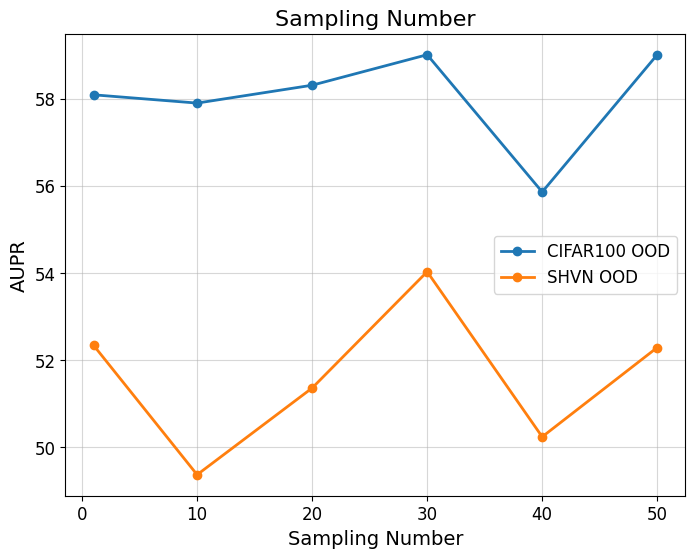

In [318]:
plt.figure(figsize=(8, 6))
plt.plot(lists, AUPR_C, marker='o', label='CIFAR100 OOD', linewidth=2)
plt.plot(lists, AUPR_S, marker='o', label='SHVN OOD', linewidth=2)

# 그래프 꾸미기
plt.title("Sampling Number", fontsize=16)
plt.xlabel("Sampling Number", fontsize=14)
plt.ylabel("AUPR", fontsize=14)
plt.grid(alpha=0.5)
plt.xticks(fontsize=12)  # x축 숫자 크기
plt.yticks(fontsize=12)  # y축 숫자 크기
plt.legend(fontsize=12)
plt.show()